# 17 · Sex × DBS interaction — effect modification by biological sex

Tests whether the DBS effect on pain differs by sex, using landmark-Δ analysis and multivariable logistic regression with interaction terms.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({ library(dplyr); library(tidyr); library(ggplot2); library(purrr); library(broom) })
rel <- load_full_ppmi_rel_patient_anchor()
rel <- rel %>% dplyr::mutate(sex_label = dplyr::case_when(SEX == 1 ~ "Male",
                                                          SEX == 0 ~ "Female",
                                                          TRUE ~ NA_character_))
cat("Sex × arm distribution:\n")
print(rel %>% dplyr::distinct(PATNO, sex_label, will_receive_dbs) %>%
        dplyr::filter(!is.na(sex_label)) %>%
        dplyr::count(sex_label, will_receive_dbs))

Warning message:
“package ‘broom’ was built under R version 4.5.2”


Sex × arm distribution:


# A tibble: 4 × 3
  sex_label will_receive_dbs     n
  <chr>     <lgl>            <int>
1 Female    FALSE              539
2 Female    TRUE                46
3 Male      FALSE              840
4 Male      TRUE                59


In [2]:
# Landmark Δ by sex × arm
rel_d <- dedup_earliest_per_bin(rel)
baseline <- rel_d %>% dplyr::filter(months >= -24, months <= 0, !is.na(NP1PAIN), !is.na(sex_label)) %>%
  dplyr::arrange(PATNO, dplyr::desc(months)) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
  dplyr::select(PATNO, will_receive_dbs, sex_label, pain_base = NP1PAIN)

landmarks <- c(6, 12, 18, 24, 36)
at_L <- function(L, tol = 6) {
  rel_d %>% dplyr::filter(!is.na(NP1PAIN), months >= L - tol, months <= L + tol) %>%
    dplyr::mutate(dist = abs(months - L)) %>%
    dplyr::arrange(PATNO, dist) %>% dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup() %>%
    dplyr::select(PATNO, NP1PAIN_L = NP1PAIN) %>% dplyr::mutate(landmark = L)
}
lm_df <- purrr::map_dfr(landmarks, at_L) %>%
  dplyr::inner_join(baseline, by = "PATNO") %>%
  dplyr::mutate(delta = NP1PAIN_L - pain_base,
                arm = dplyr::if_else(will_receive_dbs, "DBS", "Never-DBS"))

welch_sex <- purrr::map_dfr(landmarks, function(L) {
  purrr::map_dfr(c("Female","Male"), function(s) {
    d1 <- lm_df %>% dplyr::filter(landmark == L, arm == "DBS",       sex_label == s) %>% dplyr::pull(delta)
    d2 <- lm_df %>% dplyr::filter(landmark == L, arm == "Never-DBS", sex_label == s) %>% dplyr::pull(delta)
    if (length(d1) < 5 || length(d2) < 5) return(tibble::tibble(landmark = L, sex = s,
                                                                diff = NA, lo = NA, hi = NA, p = NA,
                                                                n_dbs = length(d1), n_ctl = length(d2)))
    tt <- stats::t.test(d1, d2)
    tibble::tibble(landmark = L, sex = s, diff = mean(d1) - mean(d2),
                   lo = tt$conf.int[1], hi = tt$conf.int[2], p = tt$p.value,
                   n_dbs = length(d1), n_ctl = length(d2))
  })
})
print(welch_sex)
save_table(welch_sex, "landmark_delta_by_sex")

# A tibble: 10 × 8
   landmark sex       diff     lo     hi     p n_dbs n_ctl
      <dbl> <chr>    <dbl>  <dbl>  <dbl> <dbl> <int> <int>
 1        6 Female -0.0634 -0.195 0.0683 0.338    46   539
 2        6 Male   -0.0291 -0.229 0.170  0.771    59   840
 3       12 Female  0.105  -0.281 0.492  0.584    29   215
 4       12 Male    0.0595 -0.275 0.394  0.722    38   360
 5       18 Female  0.0208 -0.320 0.362  0.903    33   251
 6       18 Male    0.167  -0.155 0.488  0.302    42   408
 7       24 Female -0.249  -0.698 0.200  0.266    22   133
 8       24 Male    0.203  -0.184 0.590  0.294    27   215
 9       36 Female  0.0594 -0.787 0.906  0.881    10    64
10       36 Male    0.120  -0.307 0.546  0.574    23    92


In [3]:
dat <- readRDS(file.path(OUT_OBJ, "patient_anchor_features.rds")) %>%
  dplyr::mutate(sex_label = dplyr::case_when(SEX == 1 ~ "Male",
                                             SEX == 0 ~ "Female",
                                             TRUE ~ NA_character_),
                dbs = as.integer(will_receive_dbs)) %>%
  dplyr::filter(!is.na(sex_label))
cat("Analytic n:", nrow(dat), "\n")

f_main <- worsened ~ dbs + sex_label + age_at_visit + LEDD + updrs3_score + pre_mean + gds
f_int  <- worsened ~ dbs * sex_label + age_at_visit + LEDD + updrs3_score + pre_mean + gds
fit_main <- stats::glm(f_main, data = dat, family = "binomial")
fit_int  <- stats::glm(f_int,  data = dat, family = "binomial")
cat("LR test (dbs × sex interaction):\n")
print(stats::anova(fit_main, fit_int, test = "Chisq"))
print(broom::tidy(fit_int, conf.int = TRUE, exponentiate = TRUE))
save_table(broom::tidy(fit_int, conf.int = TRUE, exponentiate = TRUE), "sex_dbs_interaction_logit")

Analytic n: 642 


LR test (dbs × sex interaction):


Analysis of Deviance Table

Model 1: worsened ~ dbs + sex_label + age_at_visit + LEDD + updrs3_score + 
    pre_mean + gds
Model 2: worsened ~ dbs * sex_label + age_at_visit + LEDD + updrs3_score + 
    pre_mean + gds
  Resid. Df Resid. Dev Df Deviance Pr(>Chi)
1       349     309.27                     
2       348     309.17  1 0.099466   0.7525


# A tibble: 9 × 7
  term              estimate std.error statistic p.value conf.low conf.high
  <chr>                <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 (Intercept)         0.0394  1.17        -2.77  0.00559  0.00363     0.359
2 dbs                 1.39    0.751        0.438 0.662    0.270       5.56 
3 sex_labelMale       1.03    0.330        0.104 0.917    0.547       2.01 
4 age_at_visit        1.02    0.0172       1.24  0.214    0.989       1.06 
5 LEDD                0.999   0.000438    -1.31  0.190    0.998       1.00 
6 updrs3_score        1.02    0.0115       1.67  0.0944   0.996       1.04 
7 pre_mean            0.635   0.200       -2.27  0.0231   0.420       0.923
8 gds                 1.09    0.0483       1.80  0.0712   0.990       1.20 
9 dbs:sex_labelMale   0.743   0.937       -0.316 0.752    0.117       5.03 


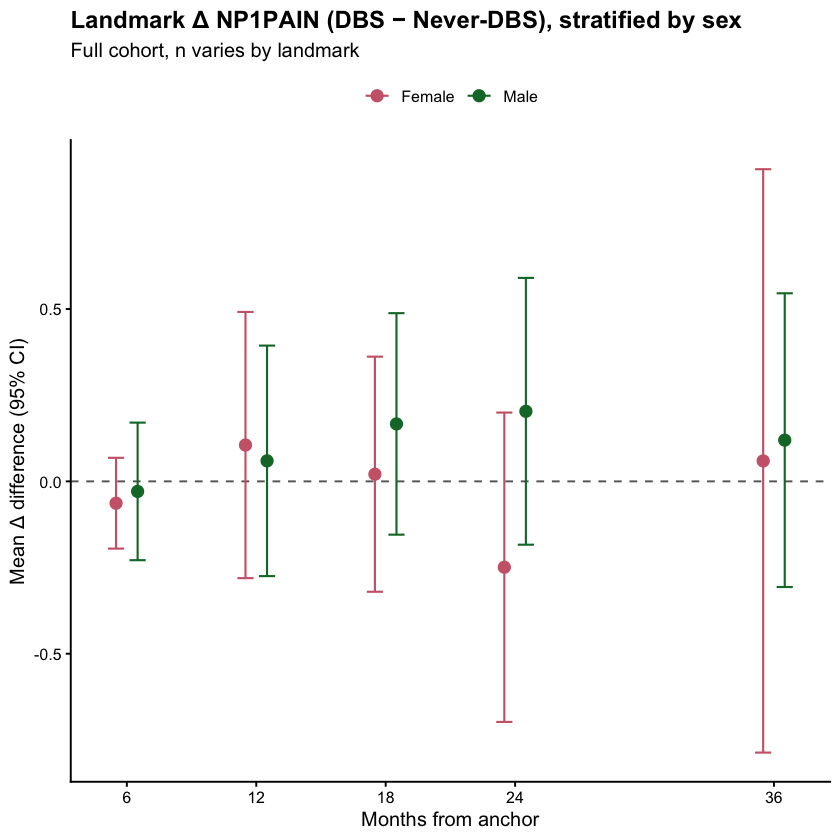

In [4]:
plot_df <- welch_sex %>% dplyr::filter(!is.na(diff))
p_sex <- ggplot(plot_df, aes(landmark, diff, colour = sex)) +
  geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  geom_errorbar(aes(ymin = lo, ymax = hi), width = 1.5, position = position_dodge(2), linewidth = 0.6) +
  geom_point(size = 3, position = position_dodge(2)) +
  scale_colour_manual(values = c(`Female` = "#CC6677", `Male` = "#117733"), name = NULL) +
  scale_x_continuous(breaks = landmarks) +
  labs(title = "Landmark Δ NP1PAIN (DBS − Never-DBS), stratified by sex",
       subtitle = "Full cohort, n varies by landmark",
       x = "Months from anchor", y = "Mean Δ difference (95% CI)") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold"), legend.position = "top")
p_sex
save_fig(p_sex, "Figure12_sex_interaction", width = 8, height = 4.6)